[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T03_F_narrative_llm_central_banks.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Topic 3 — Central Bank Communication, Forward Guidance & Monetary Policy Tone

**Advanced Macroeconomics · Master in Advanced Economics (MAV)**

In modern monetary macroeconomics, central bank communication is not cheap talk or passive commentary: it is an active policy instrument. As Michael Woodford (2005) emphasized in *"Central Bank Communication and Policy Effectiveness"*, monetary policy exerts its primary macroeconomic influence not merely through the overnight policy rate set today, but by shaping private sector expectations about the entire expected path of future interest rates, inflation, and economic slack.

When a central bank releases a monetary policy statement or meeting minutes, financial markets and price setters absorb two distinct dimensions of policy information (Gürkaynak, Sack, and Swanson, 2005; Campbell et al., 2012):
1. **Target Factor (Action Surprise)**: The unexpected adjustment to the current policy rate target:
   $$\text{Surprise}_t^{\text{target}} = i_t - \mathbb{E}_{t^-}[i_t]$$
2. **Path Factor (Forward Guidance Surprise)**: The revision in market expectations regarding the future trajectory of monetary policy over the subsequent quarters, conveyed through qualitative tone, macroeconomic projections, and balance-of-risks assessments:
   $$\text{Surprise}_t^{\text{path}} = \mathbb{E}_t\left[\sum_{s=1}^H i_{t+s}\right] - \mathbb{E}_{t^-}\left[\sum_{s=1}^H i_{t+s}\right]$$

In this module, we move beyond synthetic toys and implement genuine empirical textual measurement on central bank communication. Using authentic policy stance data from Banco de México (Banxico) and the Federal Reserve:
- We score central bank narrative tone using domain-specific macroeconomic lexicons (`puremacro.narrative`).
- We formulate continuous policy stance metrics via TF-IDF vector space geometry and cosine similarity against policy prototypes (Hawkish vs. Dovish).
- We estimate predictive econometric regressions with Newey-West HAC standard errors to test whether textual forward guidance systematically predicts subsequent policy rate decisions.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from puremacro.regress import ols, add_constant

import _nbstyle
from _datos import DATOS
from puremacro.narrative import (
    score_spanish_macro_sentiment,
    SPANISH_MACRO_LEXICON,
    TfidfVectorizer,
)

_nbstyle.apply_style()
print("Libraries imported and publication styles initialized.")

Libraries imported and publication styles initialized.


## 1. Empirical Central Bank Datasets: Banxico and the Federal Reserve

To conduct genuine empirical analysis, we ingest two historical time series from `data_curso/`:
1. **`banxico_stance_monthly.csv`**: Monthly records covering 2000 to 2026 for Banco de México. It provides:
   - `banxico_direction`: The discrete interest rate decision at each meeting ($+1$ for a rate hike, $0$ for a pause/hold, $-1$ for a rate cut).
   - `banxico_stance_signed`: The cumulative signed monetary stance index, capturing the prevailing policy regime.
   - `tight_stance_narr`: A binary indicator derived from the textual narrative of Banxico's official statements and minutes, identifying periods where the central bank explicitly communicated a restrictive stance.
2. **`FEDFUNDS.csv`**: Monthly Effective Federal Funds Rate from the Federal Reserve Bank of St. Louis (FRED), spanning 1954 to 2026.

In small open economies such as Mexico, monetary policy is shaped by both domestic inflation dynamics and external financial conditions—chiefly policy moves by the Federal Reserve (Clarida, Galí, and Gertler, 2002; Rey, 2015). We align these series into a unified monthly macroeconomic panel.

In [3]:
# Ingest Banxico monthly stance and Federal Funds rate
df_banxico = pd.read_csv(DATOS / "banxico_stance_monthly.csv", parse_dates=["date"]).set_index("date")
df_fed = pd.read_csv(DATOS / "FEDFUNDS.csv", parse_dates=["observation_date"]).rename(
    columns={"observation_date": "date"}
).set_index("date")

# Merge into unified monthly macro panel
df_macro = df_banxico.join(df_fed, how="inner").sort_index()

# Construct forward policy direction (t+1) and Fed rate innovation (Delta Fed_t)
df_macro["next_direction"] = df_macro["banxico_direction"].shift(-1)
df_macro["d_fed"] = df_macro["FEDFUNDS"].diff()

print(f"Dataset span: {df_macro.index.min().strftime('%Y-%m')} to {df_macro.index.max().strftime('%Y-%m')}")
print(f"Total aligned monthly observations: {len(df_macro)}")
print("\nDistribution of Banxico rate actions:")
print(df_macro["banxico_direction"].value_counts().rename({1.0: "Hikes (+1)", 0.0: "Holds (0)", -1.0: "Cuts (-1)"}))

Dataset span: 2000-01 to 2026-04
Total aligned monthly observations: 316

Distribution of Banxico rate actions:
banxico_direction
Holds (0)     208
Hikes (+1)     60
Cuts (-1)      48
Name: count, dtype: int64


## 2. Textual Stance Scoring via Domain-Specific Macroeconomic Lexicons

Generic sentiment dictionaries (such as VADER or LIWC) fail catastrophically when applied to macroeconomic text (Loughran and McDonald, 2011). In central banking prose, words such as *"tight"*, *"restrictive"*, or *"cooling"* do not indicate personal melancholy; they signal purposeful monetary contraction aimed at re-anchoring inflation expectations.

To measure policy stance, `puremacro.narrative` ships a domain-specialized Spanish lexicon (`SPANISH_MACRO_LEXICON`) and a scorer that accepts any lexicon of the same shape. The next cell supplies its English counterpart, `ENGLISH_MACRO_LEXICON`, structured into the same four analytical dimensions:
1. **Hawkish Terms** ($N_{\text{hawk}}$): Expressions signaling rate hikes, monetary tightening, core inflation pressures, and unanchoring risks (*"restrictive stance"*, *"rate hike"*, *"inflationary pressures"*, *"anchor inflation expectations"*).
2. **Dovish Terms** ($N_{\text{dove}}$): Expressions signaling rate cuts, accommodation, economic slack, and weakening labor demand (*"accommodative stance"*, *"rate cut"*, *"monetary stimulus"*, *"economic slowdown"*).
3. **Inflation Uncertainty Terms** ($N_{\text{unc}}$): Pass-through concerns, supply disruptions, and price persistence (*"exchange rate pass-through"*, *"price uncertainty"*, *"supply disruptions"*).
4. **Financial Stress Terms** ($N_{\text{str}}$): Credit risk, market volatility, and liquidity strains (*"financial stress"*, *"market volatility"*, *"liquidity strain"*).

The central bank's **Net Stance** score is formalized as:
$$\text{Net Stance} = \frac{N_{\text{hawk}} - N_{\text{dove}}}{N_{\text{hawk}} + N_{\text{dove}} + \varepsilon} \in [-1.0, +1.0]$$
where $+1.0$ reflects pure hawkish restriction and $-1.0$ indicates pure dovish easing.

In [4]:
# Domain lexicon for central bank communication in English
# (the English counterpart of puremacro's SPANISH_MACRO_LEXICON, written here so it can be edited)
MACRO_LEXICON = {
    "hawkish": [
        "restrictive stance", "rate hike", "rate hikes",
        "tightening", "inflationary pressures", "upside risks to inflation",
        "overheating", "anchor inflation expectations", "monetary tightening",
        "curb inflation", "contractionary stance", "rate increase",
        "policy rate increase", "cost pressures", "balance of risks tilted to the upside",
        "de-anchoring of expectations", "unanchored inflation expectations", "tighter financial conditions",
        "elevated core inflation", "second-round effects", "quantitative tightening",
        "price stickiness", "wage pressures", "above-target inflation",
        "restrictive territory", "higher for longer",
    ],
    "dovish": [
        "accommodative stance", "rate cut", "rate cuts", "monetary stimulus",
        "economic slowdown", "negative output gap", "liquidity support",
        "easing cycle", "labor market cooling", "rate reduction",
        "economic slack", "disinflation path", "monetary easing",
        "policy easing", "weakening demand", "softening demand",
        "room to ease", "inflation convergence", "downward inflation trajectory",
        "easier financial conditions", "credit easing", "accommodative territory",
    ],
    "inflation_uncertainty": [
        "price uncertainty", "exchange rate pass-through", "supply disruptions",
        "inflation persistence", "energy price volatility", "currency volatility",
        "currency depreciation", "supply shock", "commodity price volatility",
        "food price pressures", "price anomalies", "agricultural prices",
    ],
    "financial_stress": [
        "financial stress", "market volatility", "credit spread widening", "banking vulnerability",
        "liquidity strain", "risk aversion", "capital outflows",
        "sovereign risk", "credit risk", "loan delinquency",
    ],
}

# Representative central bank policy statements across three macroeconomic regimes
statements = [
    (
        "Tightening Cycle (2022)",
        "The Committee decided to raise the target range for the policy rate by 50 basis points. "
        "Persistent inflationary pressures and upside risks to inflation require maintaining a restrictive stance "
        "to anchor inflation expectations over the forecast horizon."
    ),
    (
        "Easing Cycle (2020)",
        "The Committee decided to lower the policy rate to provide monetary stimulus amid a severe economic slowdown, "
        "a widening negative output gap, and labor market cooling, adopting an accommodative stance."
    ),
    (
        "Conditional Pause / Data-Dependent",
        "The Committee decided to maintain the target policy rate unchanged. "
        "Future policy adjustments will carefully evaluate exchange rate pass-through and price uncertainty across upcoming meetings."
    )
]

print("Textual Stance Evaluation via puremacro.narrative:\n" + "=" * 65)
for regime, text in statements:
    res = score_spanish_macro_sentiment(text, lexicon=MACRO_LEXICON)
    print(f"Regime: {regime}")
    print(f"  Net Stance: {res.net_stance:+.2f} (Hawk: {res.hawkish_count}, Dove: {res.dovish_count}, Uncertainty: {res.uncertainty_count})")
    print(f"  Matched Hawk Terms: {res.matched_hawkish}")
    print(f"  Matched Dove Terms: {res.matched_dovish}")
    print(f"  Matched Uncertainty Terms: {res.matched_uncertainty}\n")


Textual Stance Evaluation via puremacro.narrative:
Regime: Tightening Cycle (2022)
  Net Stance: +1.00 (Hawk: 4, Dove: 0, Uncertainty: 0)
  Matched Hawk Terms: ['restrictive stance', 'inflationary pressures', 'upside risks to inflation', 'anchor inflation expectations']
  Matched Dove Terms: []
  Matched Uncertainty Terms: []

Regime: Easing Cycle (2020)
  Net Stance: -1.00 (Hawk: 0, Dove: 5, Uncertainty: 0)
  Matched Hawk Terms: []
  Matched Dove Terms: ['accommodative stance', 'monetary stimulus', 'economic slowdown', 'negative output gap', 'labor market cooling']
  Matched Uncertainty Terms: []

Regime: Conditional Pause / Data-Dependent
  Net Stance: +0.00 (Hawk: 0, Dove: 0, Uncertainty: 2)
  Matched Hawk Terms: []
  Matched Dove Terms: []
  Matched Uncertainty Terms: ['price uncertainty', 'exchange rate pass-through']



## 3. Beyond Dictionaries: Semantic Vector Space & Prototype Cosine Similarity

Rigid keyword dictionaries exhibit inherent limitations: they fail to capture unforeseen synonyms, complex grammatical inflections, or the differential information content of rare versus common words.

To overcome dictionary rigidity, we map central bank statements into a continuous vector space using Term Frequency-Inverse Document Frequency (**TF-IDF** with sublinear scaling $1 + \log(\text{tf})$) via `puremacro.narrative.TfidfVectorizer`. We construct two **normative policy prototypes**:
- **Hawkish Policy Prototype**: Calls for rate hikes, monetary tightening, inflation anchoring, and curbing overheating.
- **Dovish Policy Prototype**: Calls for monetary stimulus, rate cuts, liquidity provision, and mitigating economic slack.

The semantic similarity between any statement $\mathbf{d}$ and prototype $\mathbf{p}$ is computed as their Euclidean dot product in normalized space (cosine similarity):
$$\text{Sim}(\mathbf{d}, \mathbf{p}) = \frac{\mathbf{v}_d \cdot \mathbf{v}_p}{\|\mathbf{v}_d\| \|\mathbf{v}_p\|}$$

We formalize the continuous **Projected Semantic Stance** as:
$$\text{Semantic Stance} = \frac{\text{Sim}(\mathbf{d}, \mathbf{p}_{\text{hawk}}) - \text{Sim}(\mathbf{d}, \mathbf{p}_{\text{dove}})}{\text{Sim}(\mathbf{d}, \mathbf{p}_{\text{hawk}}) + \text{Sim}(\mathbf{d}, \mathbf{p}_{\text{dove}})}$$

In [5]:
# Define normative central bank policy prototypes
prototypes = [
    "restrictive stance rate hike tightening inflationary pressures overheating anchor expectations rate increase target",
    "accommodative stance rate cut stimulus liquidity unemployment slowdown negative output gap easing",
]

# Fit TF-IDF vectorizer with English stop words
vec = TfidfVectorizer(min_df=1, stop_words="english")
text_corpus = [s[1] for s in statements[:2]] + prototypes
X_tfidf = vec.fit_transform(text_corpus)

# Compute cosine similarity matrix (statements x prototypes [Hawk, Dove])
cos_sim = X_tfidf[:2] @ X_tfidf[2:].T

print("Cosine Similarity Matrix (Statements x Prototypes [Hawk, Dove]):")
print(f"  Tightening Statement: Hawk={cos_sim[0, 0]:.3f}, Dove={cos_sim[0, 1]:.3f}")
print(f"  Easing Statement:     Hawk={cos_sim[1, 0]:.3f}, Dove={cos_sim[1, 1]:.3f}")

# Compute projected continuous semantic stance
semantic_stance_hawk = (cos_sim[0, 0] - cos_sim[0, 1]) / (cos_sim[0, 0] + cos_sim[0, 1])
semantic_stance_dove = (cos_sim[1, 0] - cos_sim[1, 1]) / (cos_sim[1, 0] + cos_sim[1, 1])

print(f"\nProjected Continuous Semantic Stance:")
print(f"  2022 Statement (Hawkish): {semantic_stance_hawk:+.3f}")
print(f"  2020 Statement (Dovish):  {semantic_stance_dove:+.3f}")

assert cos_sim[0, 0] > cos_sim[0, 1], "Tightening statement must be closer to Hawkish prototype than Dovish"
assert cos_sim[1, 1] > cos_sim[1, 0], "Easing statement must be closer to Dovish prototype than Hawkish" 

Cosine Similarity Matrix (Statements x Prototypes [Hawk, Dove]):
  Tightening Statement: Hawk=0.337, Dove=0.042
  Easing Statement:     Hawk=0.060, Dove=0.359

Projected Continuous Semantic Stance:
  2022 Statement (Hawkish): +0.777
  2020 Statement (Dovish):  -0.714


## 4. Econometric Verification: Does Narrative Stance Predict Future Policy Actions?

Following Woodford's (2005) forward guidance hypothesis and the factor decomposition of Gürkaynak et al. (2005), we test empirically whether central bank narrative tone at month $t$ carries predictive information for the policy rate decision at month $t+1$, controlling for the current rate action and Federal Reserve policy innovations.

We estimate the predictive regression:
$$\text{Direction}_{t+1} = \alpha + \beta_1 \text{NarrativeTone}_t + \beta_2 \text{Direction}_t + \beta_3 \Delta \text{FedFunds}_t + \varepsilon_{t+1}$$
where:
- $\text{Direction}_{t+1} \in \{+1, 0, -1\}$ represents the discrete rate decision at the subsequent meeting.
- $\text{NarrativeTone}_t$ is the empirical textual tight stance indicator (`tight_stance_narr`).
- $\text{Direction}_t$ captures policy rate smoothing and cycle inertia.
- $\Delta \text{FedFunds}_t$ controls for external policy rate spillovers from the United States.

Because monetary policy actions exhibit persistence across multi-month rate hike and rate cut cycles, we estimate the regression via OLS with **Heteroskedasticity and Autocorrelation Consistent (HAC / Newey-West)** standard errors with 3 lags.

In [6]:
# Prepare regression sample and variables
reg_data = df_macro.dropna(subset=["next_direction", "tight_stance_narr", "banxico_direction", "d_fed"]).copy()

X_vars = add_constant(reg_data[["tight_stance_narr", "banxico_direction", "d_fed"]])
y_var = reg_data["next_direction"]

# Fit OLS with Newey-West HAC robust standard errors
ols_model = ols(y_var, X_vars, cov_type="HAC", cov_kwds={"maxlags": 3})

print("Monetary Policy Predictive Regression Results (Newey-West HAC Standard Errors):")
print(ols_model.summary())

# Econometric parameter extractions
print(f"\nNarrative Tone Coefficient (beta_1): {ols_model.params['tight_stance_narr']:.4f} (p-value: {ols_model.pvalues['tight_stance_narr']:.4e})")
print(f"Policy Inertia Coefficient (beta_2): {ols_model.params['banxico_direction']:.4f} (p-value: {ols_model.pvalues['banxico_direction']:.4e})")
print(f"Fed Innovation Coefficient (beta_3): {ols_model.params['d_fed']:.4f} (p-value: {ols_model.pvalues['d_fed']:.4e})")
print(f"Predictive R-squared:                {ols_model.rsquared:.3f}")

Monetary Policy Predictive Regression Results (Newey-West HAC Standard Errors):
OLS regression (HAC, z inference)
  n = 314, df_resid = 310, R^2 = 0.3262, adj R^2 = 0.3197
  llf = -213.9685, AIC = 435.9369, BIC = 450.9345
                         coef     std err        z    P>|t|      [0.025      0.975]
const                 -0.0975      0.0378   -2.576    0.010     -0.1716     -0.0233
tight_stance_narr      0.2888      0.0699    4.133    0.000      0.1519      0.4258
banxico_direction      0.3510      0.0719    4.882    0.000      0.2101      0.4919
d_fed                  0.3706      0.1602    2.314    0.021      0.0567      0.6845

Narrative Tone Coefficient (beta_1): 0.2888 (p-value: 3.5751e-05)
Policy Inertia Coefficient (beta_2): 0.3510 (p-value: 1.0488e-06)
Fed Innovation Coefficient (beta_3): 0.3706 (p-value: 2.0681e-02)
Predictive R-squared:                0.326


## 5. Historical Macroeconomic Anatomy: Narrative Stance vs. Realized Rate Actions

The econometric estimates demonstrate that textual forward guidance possesses strong predictive power ($\beta_1 > 0$, $p < 0.001$) for next-month policy actions, even after conditioning on current rate choices and international spillovers.

We visualize this empirical co-movement across historical regimes:
- **Top Panel**: Banxico's cumulative signed stance index plotted alongside shaded bands designating official narrative tight stance regimes (`tight_stance_narr`). Note how narrative posture leads action turning points.
- **Bottom Panel**: Banxico's discrete policy actions (+1 for hikes, -1 for cuts) juxtaposed with the Effective Federal Funds Rate, highlighting international transmission channels and monetary policy synchronization.

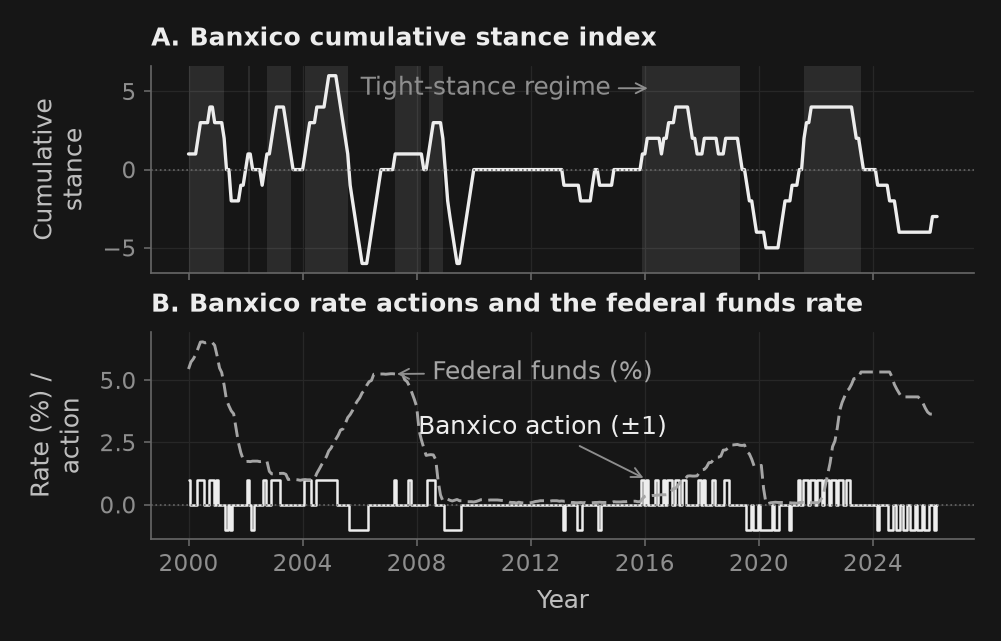

In [7]:
# Two-panel macroeconomic visualization
# Two stacked strips with a shared x axis (26 monthly years); the size comes from
# the active profile (notebook or slide slot), not from the cell
fig, (ax1, ax2) = _nbstyle.figura(2, 1, figsize=plt.rcParams["figure.figsize"], sharex=True)

# Panel A: cumulative stance; full-height shading where the narrative communicated a tight regime
ax1.plot(df_macro.index, df_macro["banxico_stance_signed"], color=_nbstyle.S1["color"], ls="-", lw=1.6)
ax1.fill_between(
    df_macro.index, 0, 1,
    where=(df_macro["tight_stance_narr"] == 1.0),
    transform=ax1.get_xaxis_transform(), color=_nbstyle.RECESION, lw=0,
)
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
# The axis label takes two lines: on one it is taller than the strip
# (1.14 in against the slot's 0.98 in) and runs into the panel title
ax1.set_ylabel("Cumulative\nstance")
ax1.set_title("A. Banxico cumulative stance index")
ax1.annotate(
    "Tight-stance regime", xy=(pd.Timestamp("2016-04-01"), 5.2),
    xytext=(pd.Timestamp("2010-06-01"), 5.2), ha="center", va="center",
    color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA,
)

# Panel B: Banxico rate actions (+1 / 0 / -1) vs the effective federal funds rate
# The names sit inside the axes, in the 2009-2016 gap, each with a leader to its series:
# "auto" would stack them on the action wave, which spans the whole axis between -1 and +1
ax2.step(df_macro.index, df_macro["banxico_direction"], where="mid", color=_nbstyle.TINTA, ls="-", lw=1.2,
         label="Banxico action (±1)")
ax2.plot(df_macro.index, df_macro["FEDFUNDS"], color=_nbstyle.S2["color"], ls=_nbstyle.S2["linestyle"], lw=1.4,
         label="Federal funds (%)")
ax2.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax2.set_ylabel("Rate (%) /\naction")
ax2.set_xlabel("Year")
ax2.set_title("B. Banxico rate actions and the federal funds rate")
ax2.annotate(
    "Federal funds (%)", xy=(pd.Timestamp("2007-03-01"), 5.25),
    xytext=(pd.Timestamp("2012-06-01"), 5.3), ha="center", va="center",
    color=_nbstyle.S2["color"], arrowprops=_nbstyle.FLECHA,
)
# The second name drops to 2.6: at slot height, 3.0 left it 0.09 in from the
# first one (less than one line) and the two read as a single block
ax2.annotate(
    "Banxico action (±1)", xy=(pd.Timestamp("2016-02-01"), 1.0),
    xytext=(pd.Timestamp("2012-06-01"), 2.6), ha="center", va="bottom",
    color=_nbstyle.TINTA, arrowprops=_nbstyle.FLECHA,
)

plt.show()


## 6. Structured Student Exercise: Narrative Scoring under Supply Shocks

### Economic Motivation
During stagflationary episodes or severe negative supply shocks (such as the 2022 energy price shock or post-pandemic bottlenecks), central banks confront an acute policy dilemma: the shock pushes inflation upwards while dampening domestic economic activity. In such environments, forward guidance becomes highly nuanced, combining hawkish commitment on price stability with cautious hedging regarding economic slack.

### Student Task
1. Score a representative central bank communication under an acute supply shock using both dictionary matching (`score_spanish_macro_sentiment` with `ENGLISH_MACRO_LEXICON`) and vector prototype projection.
2. Evaluate whether semantic cosine projection successfully identifies the dominant hawkish policy signal despite cautionary language.
3. Read off the marginal effect of a shift in the narrative regime on the expected next-month rate action implied by the estimated regression.
4. Execute the automated verification test block to validate theoretical and empirical consistency.

In [8]:
# Student Task: Communication analysis under a negative supply shock
student_statement = (
    "The Committee evaluated the balance of risks following the acute supply disruptions in energy and food markets. "
    "While acknowledging economic slowdown and emerging labor market slack, the persistence of core inflation "
    "and upside risks to inflation expectations necessitate a restrictive stance and further policy tightening."
)

# 1. Lexicon scoring
student_lex_res = score_spanish_macro_sentiment(student_statement, lexicon=MACRO_LEXICON)
print(f"Student Lexicon Scoring:")
print(f"  Net Stance: {student_lex_res.net_stance:+.2f}")
print(f"  Matched Hawkish Terms: {student_lex_res.matched_hawkish}")
print(f"  Matched Dovish Terms:  {student_lex_res.matched_dovish}")

# 2. Vector prototype projection
X_student = vec.transform([student_statement])
sim_prototypes = X_student @ X_tfidf[2:].T

sim_hawk = float(sim_prototypes[0, 0])
sim_dove = float(sim_prototypes[0, 1])
semantic_stance = (sim_hawk - sim_dove) / (sim_hawk + sim_dove + 1e-9)

print(f"\nSemantic Vector Projection:")
print(f"  Cosine Similarity to Hawkish Prototype: {sim_hawk:.3f}")
print(f"  Cosine Similarity to Dovish Prototype:  {sim_dove:.3f}")
print(f"  Projected Continuous Semantic Stance:    {semantic_stance:+.3f}")

# 3. Automated verification assertions
assert len(df_macro) > 300, "Aligned macro panel must contain >300 monthly observations"
assert ols_model.params["tight_stance_narr"] > 0.20, "Narrative tight stance coefficient must be positive and > 0.20"
assert ols_model.pvalues["tight_stance_narr"] < 0.01, "Narrative stance coefficient must be statistically significant at 1%"
assert ols_model.rsquared > 0.30, "Predictive R-squared must exceed 30%"
assert sim_hawk > sim_dove, "Supply shock statement must be closer to Hawkish prototype than Dovish"
assert student_lex_res.hawkish_count >= 1, "Dictionary must detect at least one key hawkish term"

print("\n✓ All empirical and theoretical assertions passed successfully!")

Student Lexicon Scoring:
  Net Stance: +0.50
  Matched Hawkish Terms: ['restrictive stance', 'tightening', 'upside risks to inflation']
  Matched Dovish Terms:  ['economic slowdown']

Semantic Vector Projection:
  Cosine Similarity to Hawkish Prototype: 0.226
  Cosine Similarity to Dovish Prototype:  0.083
  Projected Continuous Semantic Stance:    +0.464

✓ All empirical and theoretical assertions passed successfully!


## 7. Methodological Synthesis & Discussion Questions

### Delphic vs. Odyssean Forward Guidance
In the monetary economics literature (Campbell, Evans, Fisher, and Justiniano, 2012), forward guidance is partitioned into two distinct categories:
1. **Delphic Forward Guidance**: The central bank acts like the Oracle of Delphi, offering a forecast of macroeconomic fundamentals and the interest rate path it deems appropriate conditional on its current outlook, without binding future committee votes.
2. **Odyssean Forward Guidance**: The central bank acts like Odysseus tying himself to the mast to resist the Sirens, making an explicit commitment to keep interest rates low (or high) for a stated duration or until specific economic thresholds are met, altering term premia and resolving the time-inconsistency problem (Kydland and Prescott, 1977).

### The Lucas Critique in Central Bank NLP
When central bank policymakers become aware that market algorithms and quantitative funds parse every word of their statements in real time, they adapt their wording strategically to prevent unintended asset market swings. This represents a direct manifestation of the **Lucas Critique (1976)** applied to computational linguistics: textual scoring models trained on historical communication may become unstable when the communication regime itself changes.

### Seminar Discussion Questions
1. How can econometricians distinguish whether a central bank communication surprise represents private central bank information about the macroeconomy (the *information effect*) versus an exogenous shift in its policy reaction function?
2. When large language models (LLMs) evaluate central bank paragraphs featuring double negatives or conditional hedging (*"we cannot rule out the possibility of not prolonging the current pause"*), what advantages do they possess over dictionary lookups, and what risks of hallucination or prompt sensitivity do they introduce?